In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [10]:
path = r'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\mesh_analysis\mesh0.xlsx'

In [11]:
df = pd.read_excel(path, header = 1).drop(0)

In [12]:
df

,Frequencies),Amplitude
1,0.002441,0.003122
2,0.004883,0.003133
3,0.007324,0.003179
4,0.009766,0.002926
5,0.012207,0.002929
...,...,...
2044,4.990234,0.000030
2045,4.992676,0.000030
2046,4.995117,0.000030
2047,4.997559,0.000030


In [15]:
ancho_banda = df['Frequencies)'][2]-df['Frequencies)'][1]
ancho_banda

0.0024414062500001388

In [19]:
df['density'] = 0.5 * (df['Amplitude']**(2)*ancho_banda)
df

,Frequencies),Amplitude,density
1,0.002441,0.003122,1.189772e-08
2,0.004883,0.003133,1.198245e-08
3,0.007324,0.003179,1.234011e-08
4,0.009766,0.002926,1.045080e-08
5,0.012207,0.002929,1.047284e-08
...,...,...,...
2044,4.990234,0.000030,1.068712e-12
2045,4.992676,0.000030,1.068662e-12
2046,4.995117,0.000030,1.068750e-12
2047,4.997559,0.000030,1.068776e-12


In [21]:
frequency = df['Frequencies)'].values
density = df['density'].values

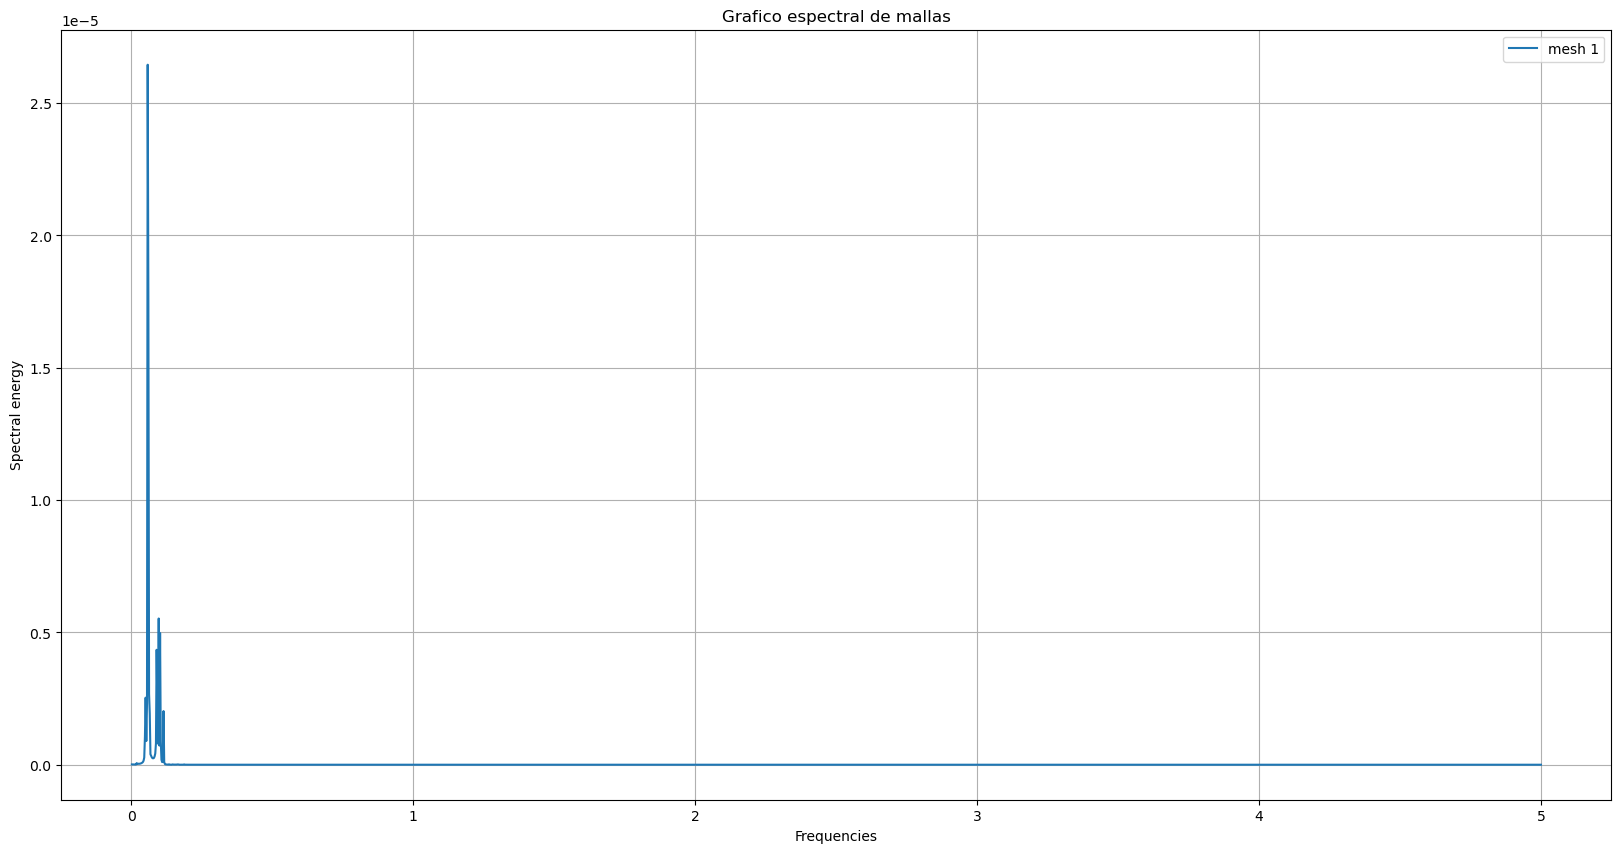

In [26]:
plt.figure(figsize=(20,10))
plt.plot(frequency, density, label = 'mesh 1')

plt.title('Grafico espectral de mallas')
plt.xlabel('Frequencies')
plt.ylabel('Spectral energy')
plt.legend()
plt.grid()

## bucle para representar todas las mallas

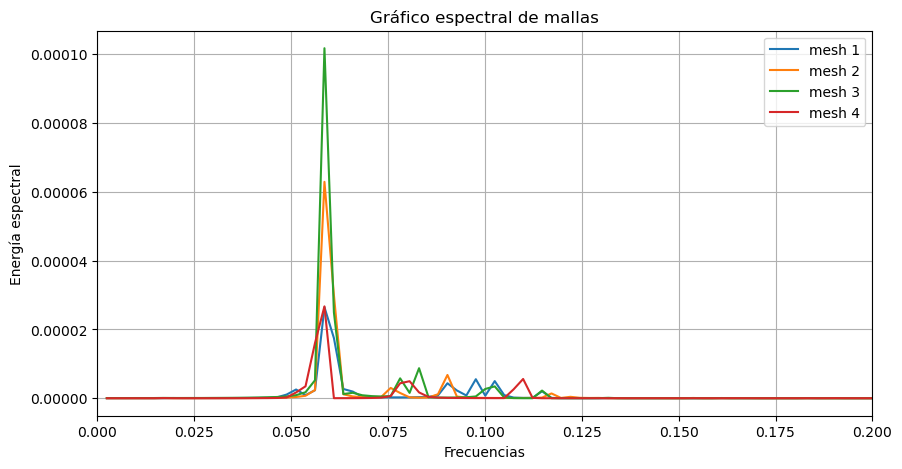

In [35]:
frequencies_list = []
density_list = []

for mesh in range(0,4):
    path = rf'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\mesh_analysis\mesh{mesh}.xlsx'
    df = pd.read_excel(path, header = 1).drop(0)

    ancho_banda = df['Frequencies)'][2]-df['Frequencies)'][1]
    df['density'] = 0.5 * (df['Amplitude']**(2)*ancho_banda)

    frequency = df['Frequencies)'].values
    density = df['density'].values

    frequencies_list.append(frequency)
    density_list.append(density)


plt.figure(figsize=(10, 5))
for mesh, (frequency, density) in enumerate(zip(frequencies_list, density_list), start=1):
    plt.plot(frequency, density, label=f'mesh {mesh}')

plt.xlim(0,0.2)
plt.title('Gráfico espectral de mallas')
plt.xlabel('Frecuencias')
plt.ylabel('Energía espectral')
plt.legend()
plt.grid()

plt.savefig(r'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\mesh_analysis\mesh_comparative.png', dpi=300, bbox_inches='tight')

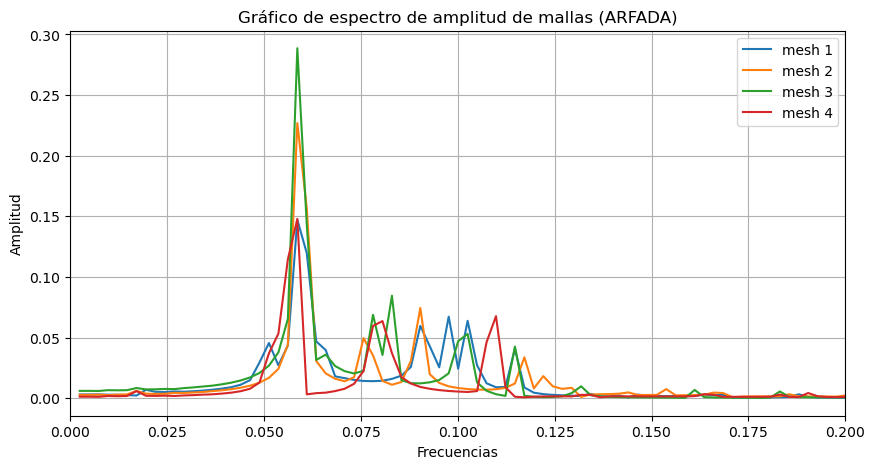

In [40]:
frequencies_list = []
amplitude_list = []

for mesh in range(0,4):
    path = rf'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\mesh_analysis\mesh{mesh}.xlsx'
    df = pd.read_excel(path, header = 1).drop(0)

    frequency = df['Frequencies)'].values
    amplitude = df['Amplitude'].values

    frequencies_list.append(frequency)
    amplitude_list.append(amplitude)

plt.figure(figsize=(10, 5))
for mesh, (frequency, amplitude) in enumerate(zip(frequencies_list, amplitude_list), start=1):
    plt.plot(frequency, amplitude, label=f'mesh {mesh}')

plt.xlim(0,0.2)
plt.title('Gráfico de espectro de amplitud de mallas (ARFADA)')
plt.xlabel('Frecuencias')
plt.ylabel('Amplitud')
plt.legend()
plt.grid()

plt.savefig(r'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\mesh_analysis\mesh_amplitude_comparative.png', dpi=300, bbox_inches='tight')